In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("All libraries loaded")

All libraries loaded


In [7]:
import os
print(os.getcwd())

/Users/sonikagupta/Desktop/GitDemo/mutual-fund-analytics/notebooks


In [8]:
funds = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
perf = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
txn = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("Data Loaded Successfully")

Data Loaded Successfully


In [9]:
print("AUM Columns")
print(aum.columns)

print("\nTransaction Columns")
print(txn.columns)

print("\nCategory Columns")
print(category.columns)

print("\nFolio Columns")
print(folio.columns)

print("\nHoldings Columns")
print(holdings.columns)

AUM Columns
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')

Transaction Columns
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

Category Columns
Index(['month', 'category', 'net_inflow_crore'], dtype='object')

Folio Columns
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')

Holdings Columns
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


Chart 1 : AUM Growth by Fund house

<Figure size 1400x600 with 0 Axes>

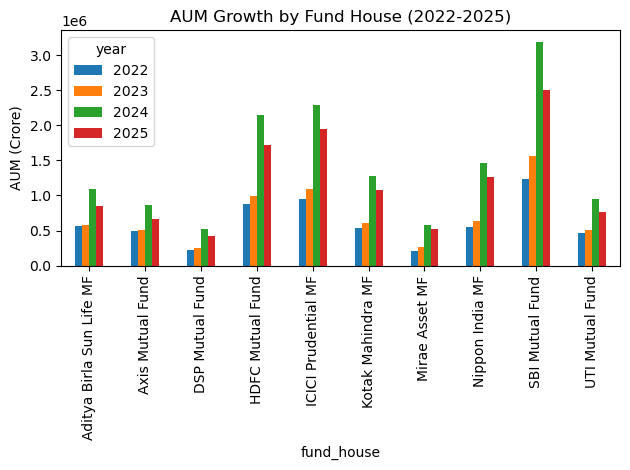

In [10]:
aum["year"] = pd.to_datetime(aum["date"]).dt.year

pivot_aum = aum.pivot_table(
    index="fund_house",
    columns="year",
    values="aum_crore",
    aggfunc="sum"
)

plt.figure(figsize=(14,6))
pivot_aum.plot(kind="bar")

plt.title("AUM Growth by Fund House (2022-2025)")
plt.ylabel("AUM (Crore)")
plt.tight_layout()

plt.savefig("../reports/charts/aum_growth.png")
plt.show()

Chart 2 : SIP Monthly Trend 

In [21]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows"
)
plt.savefig("../reports/charts/sip_inflows.png")

fig.show()

<Figure size 640x480 with 0 Axes>

Chart 3 : Category Inflow Heatmap

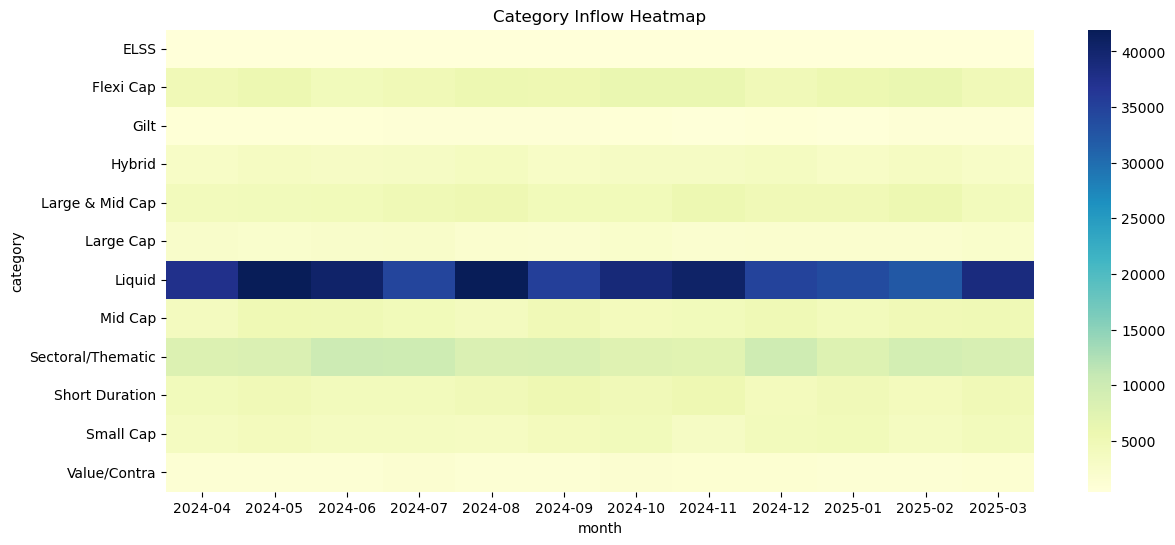

In [22]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)
plt.savefig("../reports/charts/category_inflow_heatmap.png")

plt.title("Category Inflow Heatmap")
plt.show()

Chart 4 : Age Group Pie Chart 

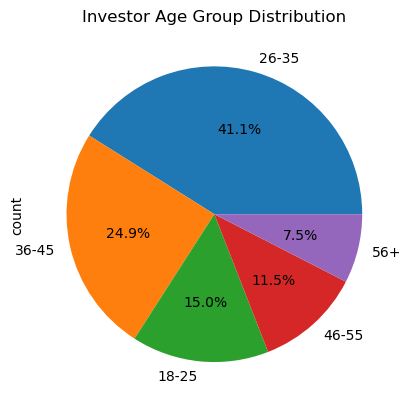

In [23]:
txn["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.savefig("../reports/charts/age_group_distribution.png")

plt.title("Investor Age Group Distribution")
plt.show()

Chart 5 : Gender Split

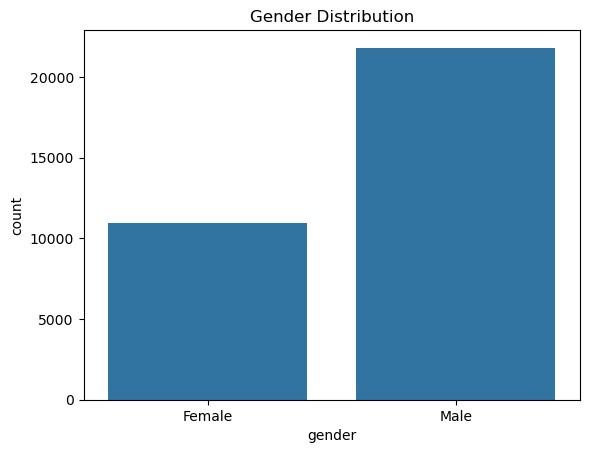

In [24]:
sns.countplot(
    data=txn,
    x="gender"
)

plt.title("Gender Distribution")
plt.savefig("../reports/charts/gender_distribution.png")
plt.show()

Chart 6 : State-Wise SIP Amount 

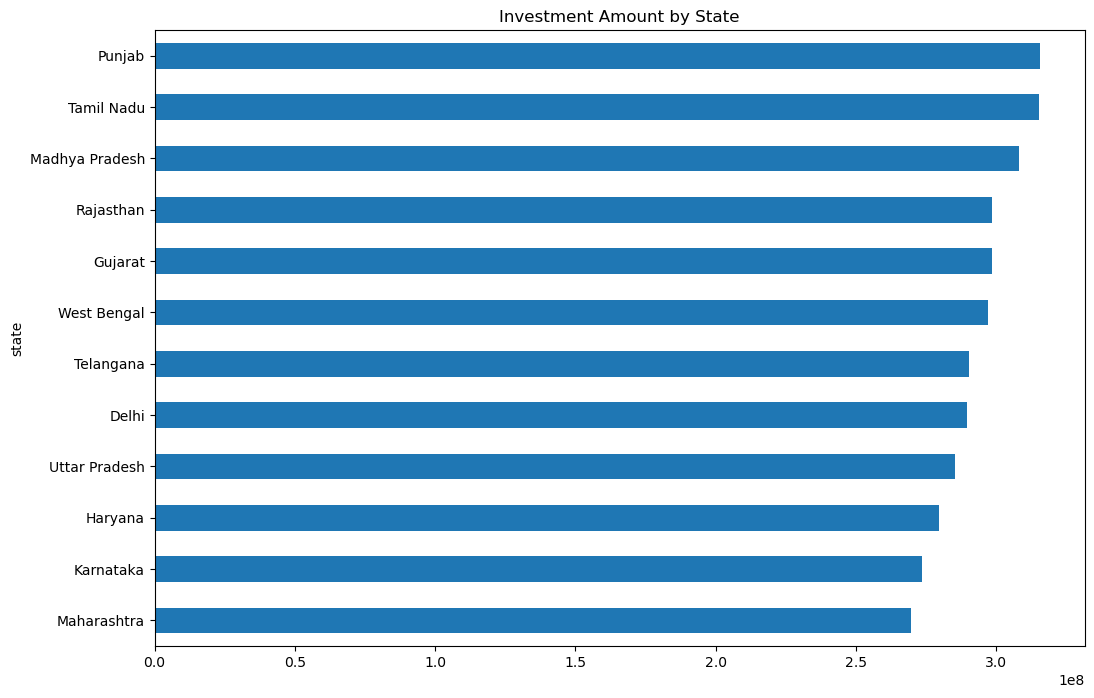

In [25]:
state_sip = (
    txn.groupby("state")["amount_inr"]
       .sum()
       .sort_values()
)

state_sip.plot(
    kind="barh",
    figsize=(12,8)
)

plt.title("Investment Amount by State")
plt.savefig("../reports/charts/state_investment.png")
plt.show()

Chart 7: T30 vs B30

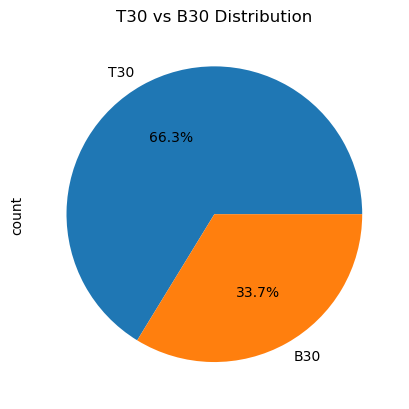

In [26]:
txn["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Distribution")
plt.savefig("../reports/charts/city_tier_distribution.png")
plt.show()

Chart 8: Folio Growth

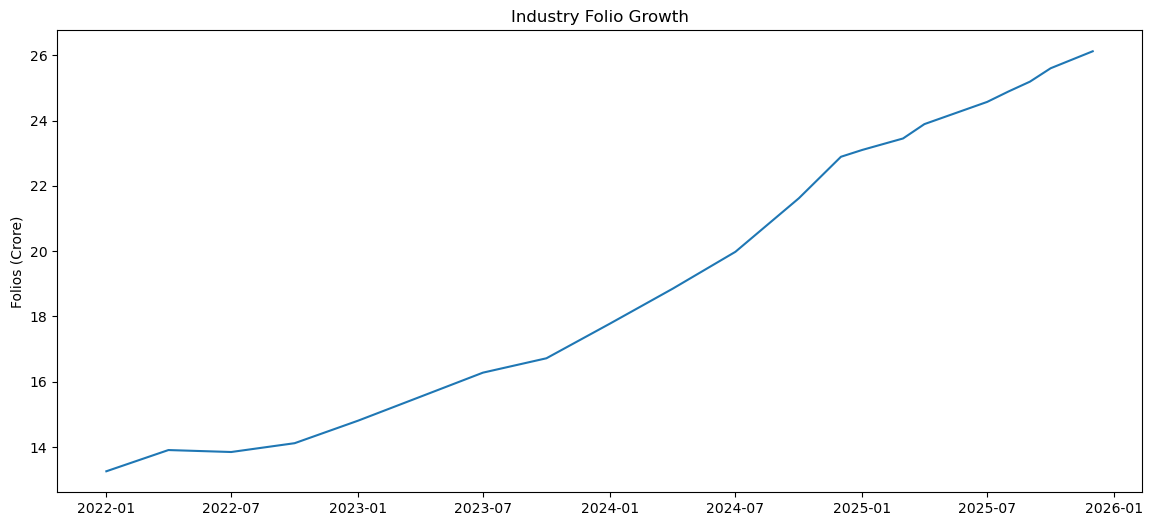

In [27]:
folio["month"] = pd.to_datetime(
    folio["month"]
)

plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.title("Industry Folio Growth")
plt.ylabel("Folios (Crore)")
plt.savefig("../reports/charts/industry_folio_growth.png")
plt.show()

Chart 9: Sector Allocation Donut

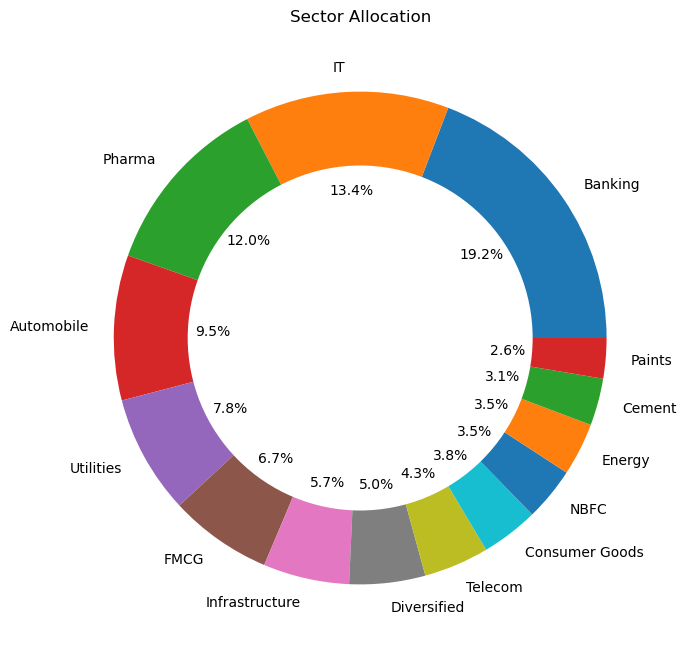

In [28]:
sector_data = (
    holdings.groupby("sector")
            ["weight_pct"]
            .sum()
            .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%"
)

centre = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre)

plt.title("Sector Allocation")
plt.savefig("../reports/charts/sector_allocation.png")
plt.show()

Chart 10: NAV Correlation Matrix

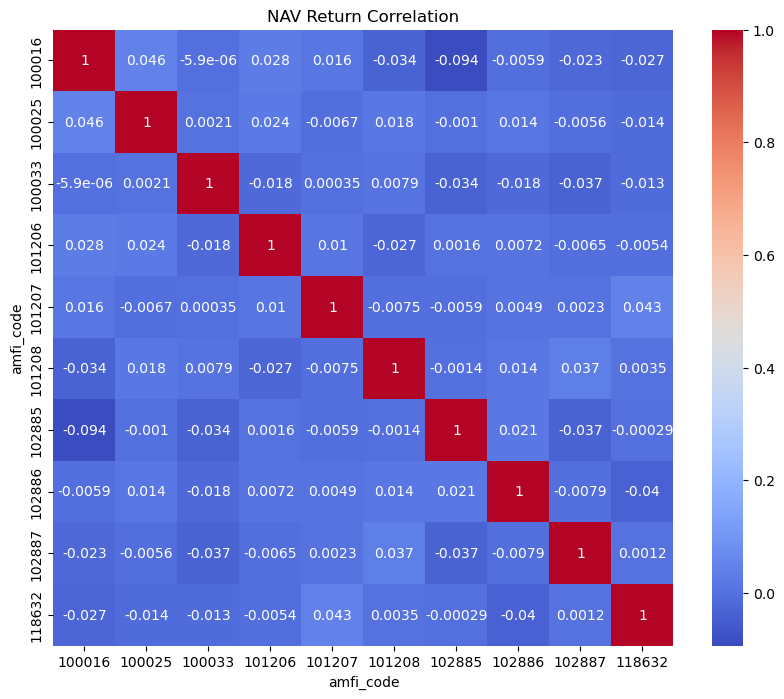

In [29]:
nav["date"] = pd.to_datetime(nav["date"])

top_funds = (
    nav["amfi_code"]
    .unique()[:10]
)

pivot_nav = nav[
    nav["amfi_code"].isin(top_funds)
].pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot_nav.pct_change()

corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation")
plt.savefig("../reports/charts/nav_return_correlation.png")
plt.show()

# EDA Finding 1

Mutual fund AUM showed consistent growth from 2022 to 2025, indicating increasing investor participation.

# EDA Finding 2

SBI Mutual Fund maintained the highest AUM among major fund houses, demonstrating strong market leadership.

# EDA Finding 3

Monthly SIP inflows displayed an upward trend, reflecting growing retail investor confidence.

# EDA Finding 4

Certain fund categories attracted significantly higher inflows than others, indicating investor preference concentration.

# EDA Finding 5

The majority of investors belong to the middle-age groups, making them the dominant contributor to mutual fund investments.

# EDA Finding 6

Male investors constitute a larger share of the investor base compared to female investors.

# EDA Finding 7

T30 cities contribute a significant share of investments, though B30 participation is also increasing.

# EDA Finding 8

A few states contribute a disproportionately large share of total investment amounts.

# EDA Finding 9

Industry folio counts increased steadily between 2022 and 2025, indicating expansion of the mutual fund ecosystem.

# EDA Finding 10

Most large-cap equity funds exhibit positive return correlations, reflecting common exposure to broader market movements.


In [20]:
import os

os.makedirs(
    "../reports/charts",
    exist_ok=True
)

print("Charts folder ready")

Charts folder ready


In [30]:
import os

print(os.listdir("../reports/charts"))

['aum_growth.png', 'category_inflow_heatmap.png', 'age_group_distribution.png', 'sector_allocation.png', 'industry_folio_growth.png', 'sip_inflows.png', 'city_tier_distribution.png', 'state_investment.png', 'gender_distribution.png', 'nav_return_correlation.png']


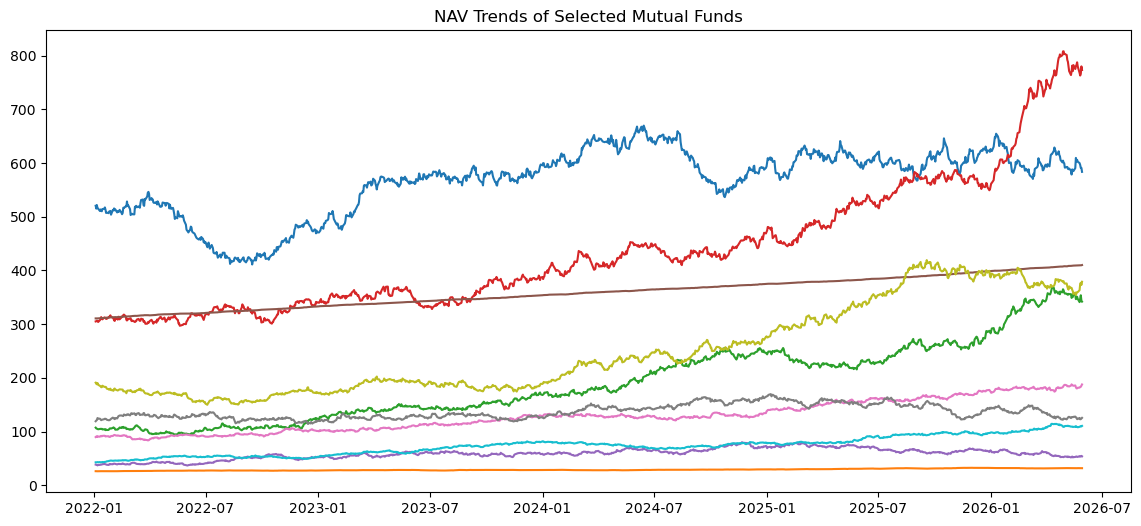

In [31]:
nav["date"] = pd.to_datetime(nav["date"])

plt.figure(figsize=(14,6))

for code in nav["amfi_code"].unique()[:10]:
    temp = nav[nav["amfi_code"] == code]
    plt.plot(temp["date"], temp["nav"])

plt.title("NAV Trends of Selected Mutual Funds")

plt.savefig("../reports/charts/nav_trend.png")

plt.show()